# Image filtering

In [1]:
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv
# this is only necessary for executing in colab
%matplotlib inline

In [2]:
img = cv.imread('./Trump.jpg')
# print some information about the image
print(img.shape)
print(type(img))

(733, 1100, 3)
<class 'numpy.ndarray'>


So, now we know that our image has a certain size and is stored as a ```numpy``` array of - in this case - three dimensions.

Now, let's next look at the image using OpenCV's built-in ```imshow``` function like so:

In [3]:
# let's make the image first a bit smaller
scale_percent = 50 # percent of original size
width = int(img.shape[1] * scale_percent / 100)
height = int(img.shape[0] * scale_percent / 100)
dim = (width, height)
# resize image
rimg = cv.resize(img, dim, interpolation = cv.INTER_AREA)


Let's use ```matplotlib``` to show the picture

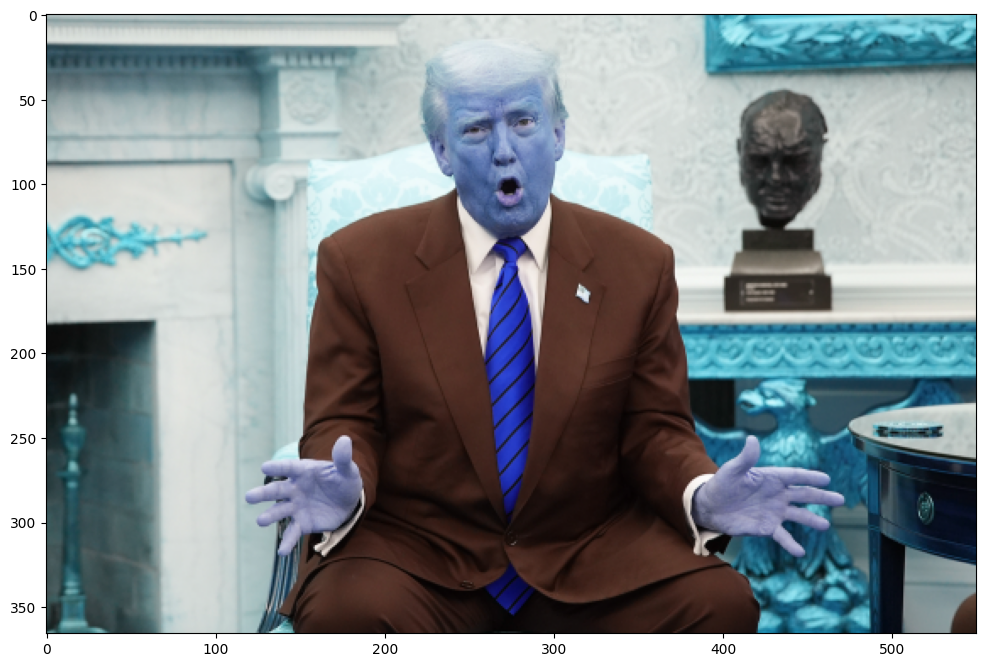

In [4]:
plt.figure(None, figsize=(12, 12))
plt.imshow(rimg)
plt.show()

Urgh. The colors are completely different.

This is because OpenCV stores images in BGR (BLUE - GREEN - RED) format, rather than the usual RGB (RED - GREEN - BLUE) format from other languages. So, if we want to show the image properly with ```matplotlib``` we have to convert the image first.

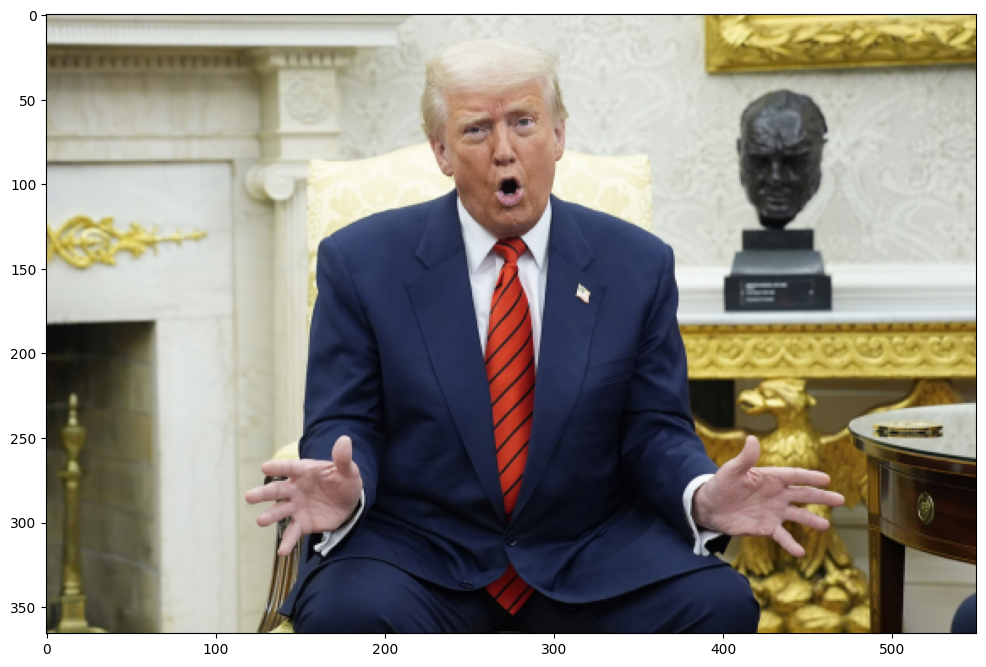

In [5]:
mrimg = cv.cvtColor(rimg, cv.COLOR_BGR2RGB)
plt.figure(None, figsize=(12, 12))
plt.imshow(mrimg)
plt.show()

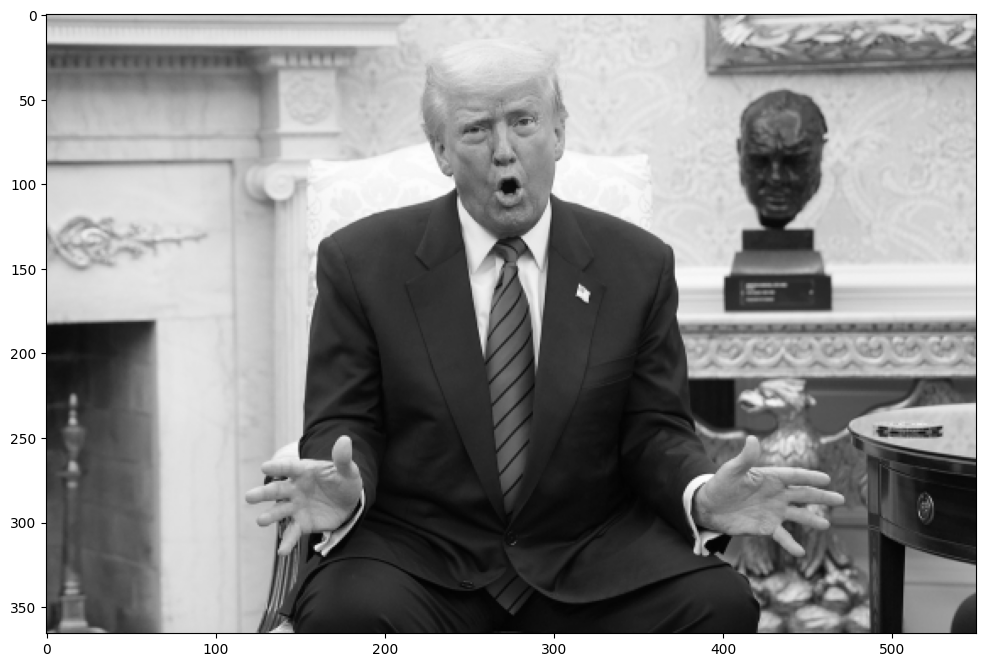

In [6]:
mrimg = cv.cvtColor(rimg, cv.COLOR_BGR2GRAY)
plt.figure(None, figsize=(12, 12))
plt.imshow(mrimg,cmap='gray')
plt.show()

Now, let's cut out a section of the image and let's display it as a grid of values. Most of the code below is to make sure that the plotting works fine and that we can add the pixel intensity values in a nice way to the plot.

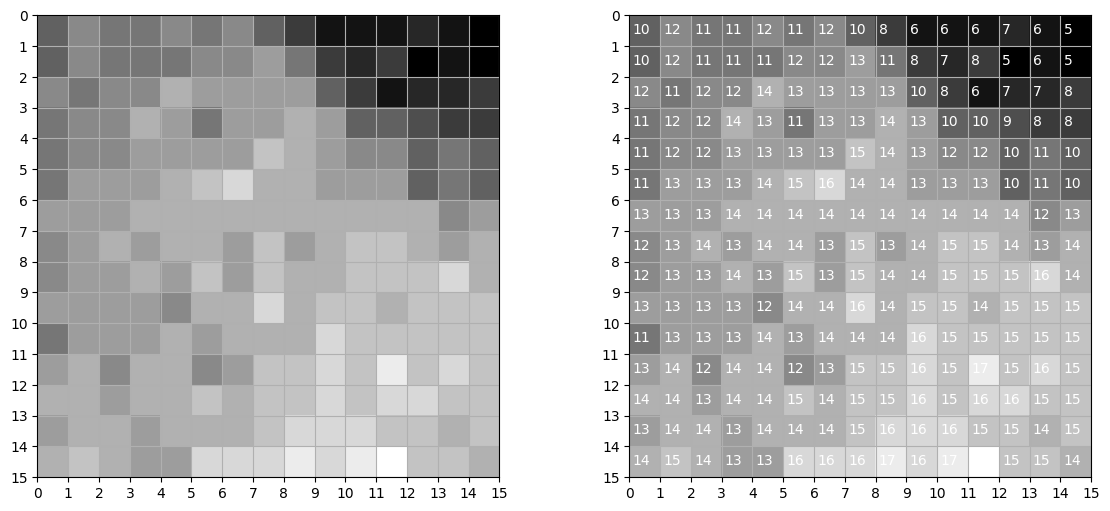

In [8]:
roi = mrimg[350:365,290:305]
# the extent variable is important for ensuring the right
# kind of plotting area!
extent = (0, roi.shape[1], roi.shape[0], 0)
plt.figure(None, figsize=(14, 6))
plt.subplot(1,2,1)
plt.imshow(roi,cmap='gray',extent=extent)
ax = plt.gca()
# this makes sure we have the correct grid lines
major_ticks = np.arange(0, 16, 1)
ax.set_xticks(major_ticks)
ax.set_yticks(major_ticks)
plt.grid(True)
plt.subplot(1,2,2)
plt.imshow(roi,cmap='gray',extent=extent)
ax = plt.gca()
major_ticks = np.arange(0, 16, 1)
ax.set_xticks(major_ticks)
ax.set_yticks(major_ticks)
# plots pixel intensity values with text color depending on
# the pixel value
for i in range(0,15):
    for j in range(0,15):
        if roi[j,i]>127:
            plt.text(i+0.1,j+0.6,str(roi[j,i]),color='black')
        else:
            plt.text(i+0.1,j+0.6,str(roi[j,i]),color='white')
plt.grid(True)

Next, let's plot the image function F(x,y) as a surface.

In [9]:
# definition of x and y and meshgrid
x = np.arange(0, mrimg.shape[1], 1)
y = np.arange(0, mrimg.shape[0], 1)
xx, yy = np.meshgrid(x, y)

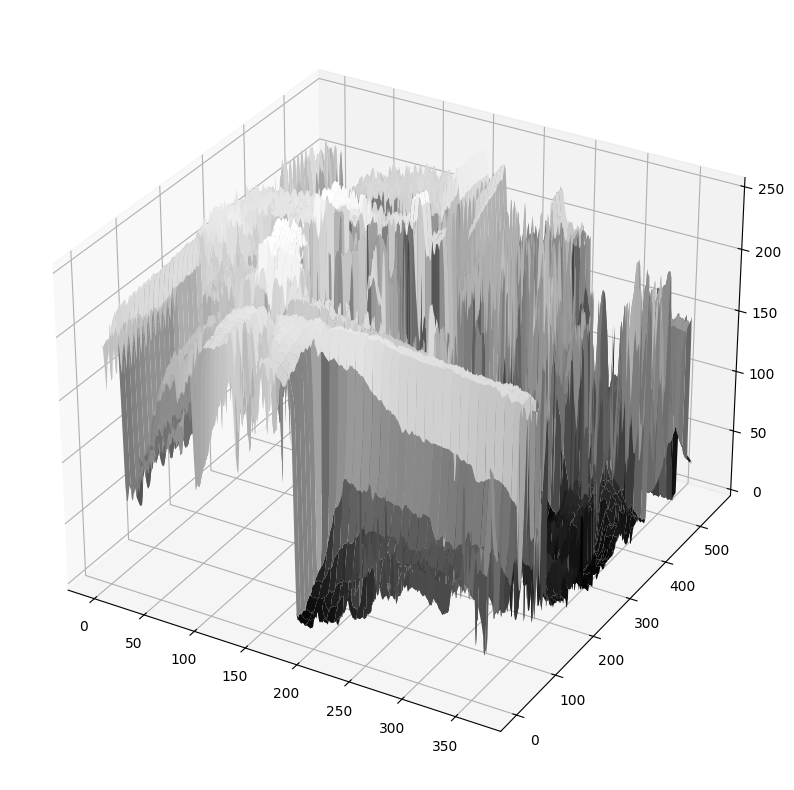

In [10]:
# code how to do this in Matplotlib, which does NOT work well within Colab
fig = plt.figure(None, figsize=(10, 10))
ax = fig.add_subplot(projection='3d')
ax.plot_surface(yy,xx,mrimg[yy,xx],cmap='gray')
plt.show()

In [12]:
# code how to do this with plotly, which works well within Colab
import plotly.graph_objects as go

fig = go.Figure(data=[go.Surface(z=mrimg[yy,xx])])

fig.update_layout(title='Image Surface', autosize=False,
                  width=500, height=500,
                  margin=dict(l=65, r=50, b=65, t=90))

fig.show()

## Arithmetics with images

Let's add something to our function

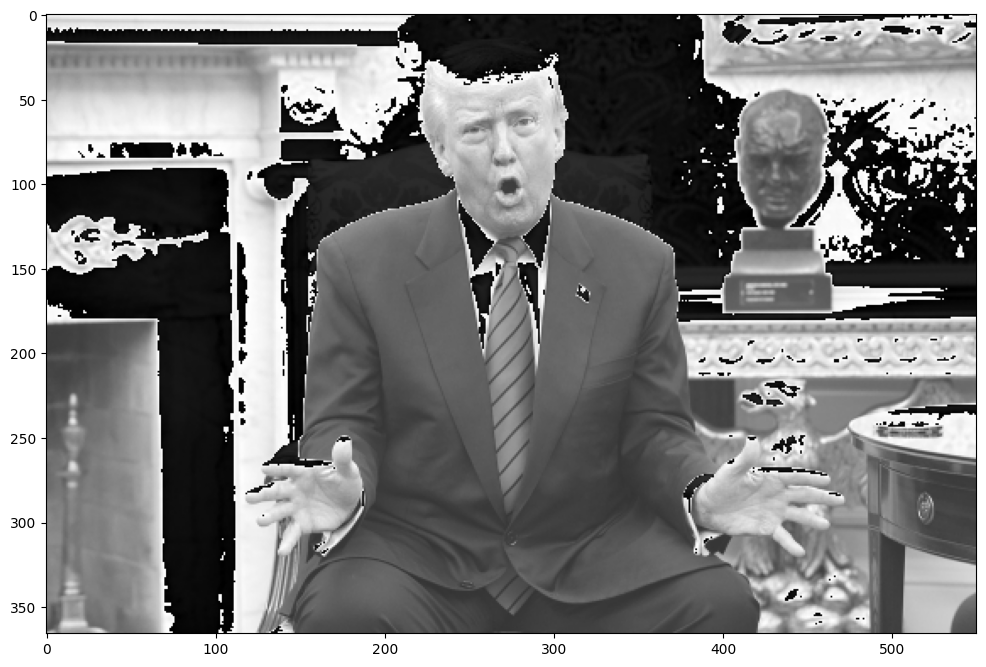

In [13]:
plt.figure(None, figsize=(12, 12))
plt.imshow(mrimg+50,cmap='gray')
plt.show()

That result cannot be correct - some parts of the image turn black, when actually the whole image should get brighter. This is because of clipping!

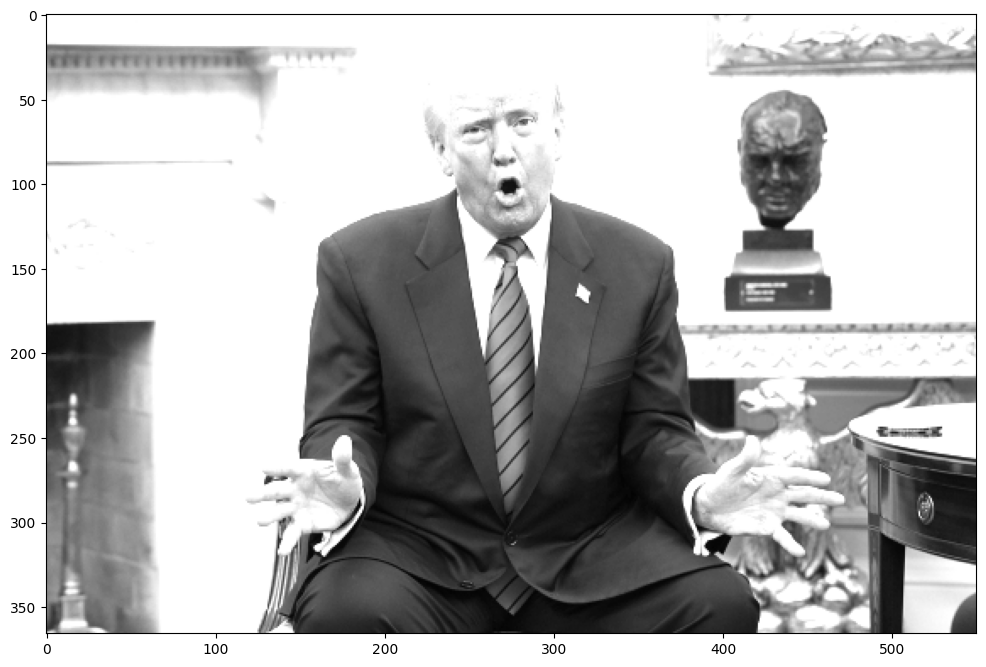

In [14]:
plt.figure(None, figsize=(12, 12))
plt.imshow(np.clip(mrimg.astype(float)+100,0,255),cmap='gray')
plt.show()

Here's the inverse of the image

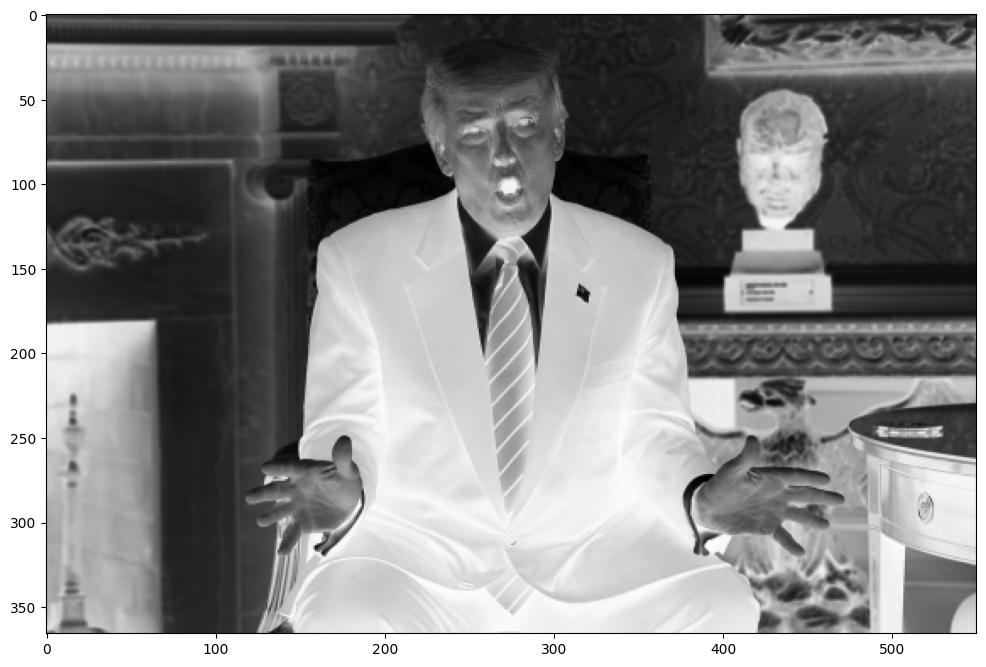

In [15]:
plt.figure(None, figsize=(12, 12))
plt.imshow(255-mrimg,cmap='gray')
plt.show()

# Filtering

Let's apply our simple retina-like filter to a signal

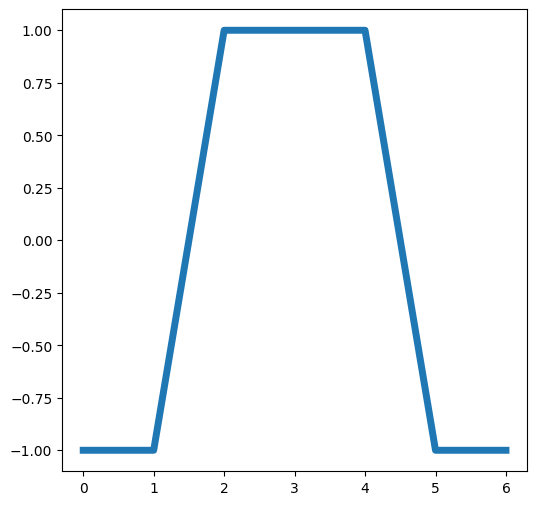

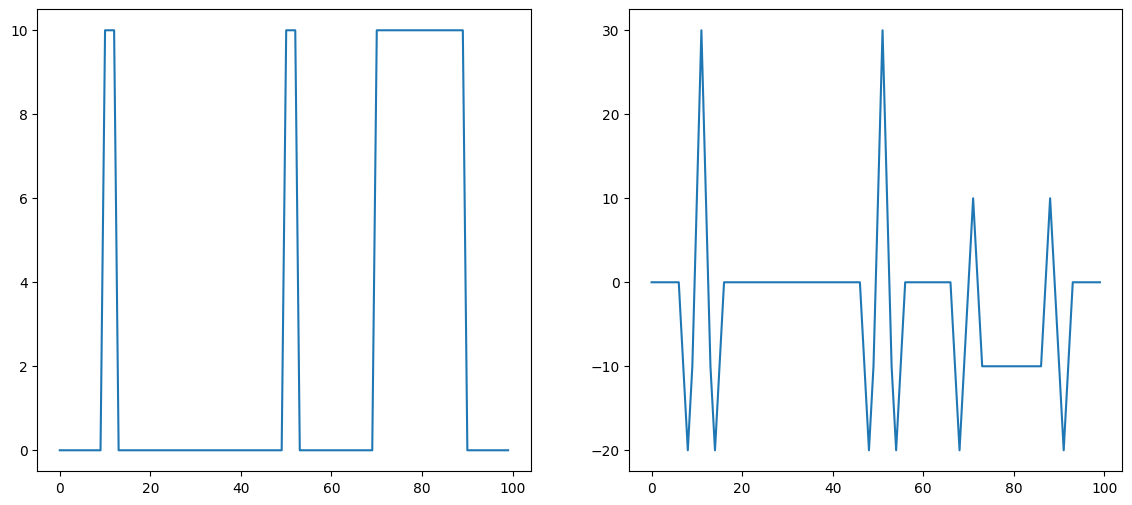

In [16]:
signal = np.zeros((100,1))
signal[10:13]=10;
signal[50:53]=10;
signal[70:90]=10;

filtered_signal = np.zeros_like(signal)
weights = np.array((-1.0,-1.0,1.0,1.0,1.0,-1.0,-1.0))
plt.figure(None, figsize=(6, 6))
plt.plot(weights,linewidth=5)
for i in range(3,len(signal)-3):
    filtered_signal[i]=np.dot(weights,signal[i-3:i+4])

plt.figure(None, figsize=(14, 6))
plt.subplot(1,2,1)
plt.plot(signal)
plt.subplot(1,2,2)
plt.plot(filtered_signal)
plt.show()

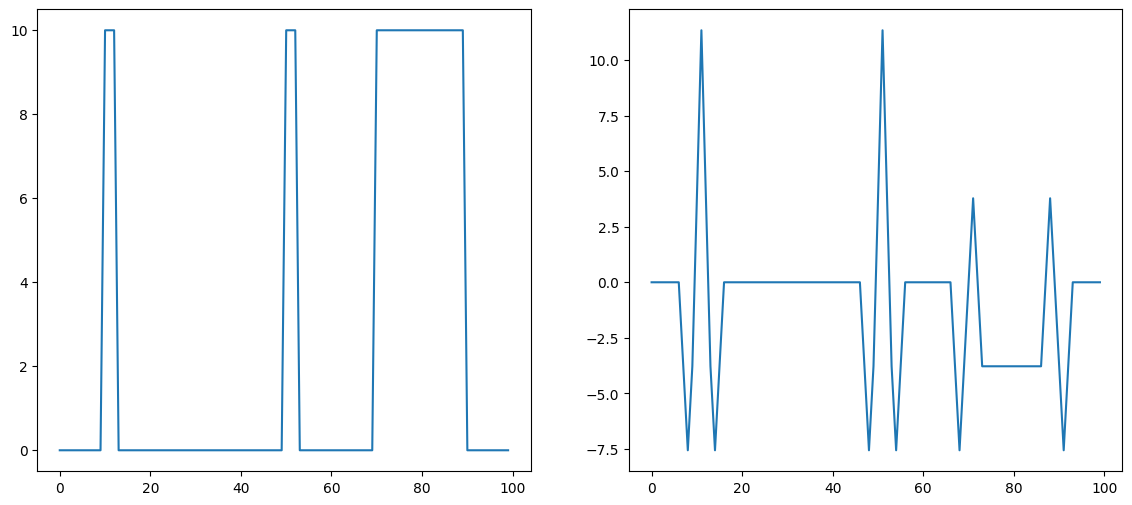

In [17]:
weights = np.array((-1,-1,1,1,1,-1,-1))
weights = weights/np.linalg.norm(weights, ord=2, keepdims=True)
for i in range(3,len(signal)-3):
    filtered_signal[i]=np.dot(weights,signal[i-3:i+4])

plt.figure(None, figsize=(14, 6))
plt.subplot(1,2,1)
plt.plot(signal)
plt.subplot(1,2,2)
plt.plot(filtered_signal)
plt.show()

## Scanline
Let's see what the image function says for our picture at one scanline.

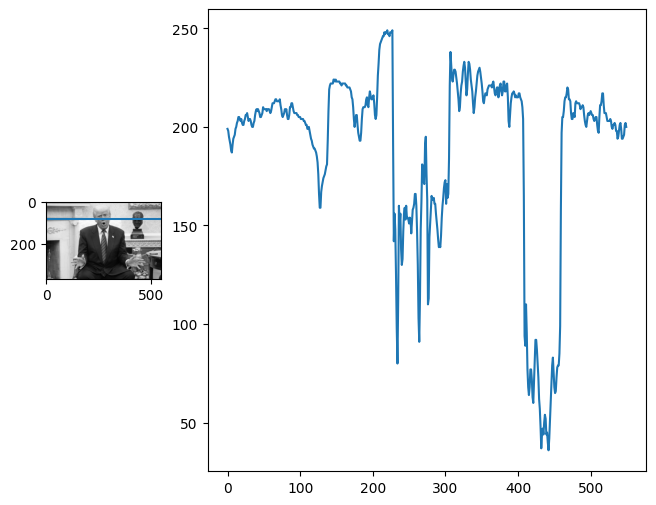

In [21]:
cuty = 80
plt.figure(None, figsize=(14, 6))
grid = plt.GridSpec(1, 7, wspace=0.4, hspace=0.3)
plt.subplot(grid[0, 0])
plt.imshow(mrimg,cmap='gray')
plt.plot((0,mrimg.shape[1]-1),(cuty,cuty))
plt.subplot(grid[0, 1:4])
oneline = mrimg[cuty,:]
plt.plot(oneline)
plt.show()

## Filtering one image line
Let's apply our filter to the scanline in the image.

In [22]:
newoneline = np.zeros_like(oneline)
weights = (-1,-1,1,1,1,-1,-1)
for i in range(3,len(oneline)-3):
    newoneline[i]=np.dot(weights,oneline[i-3:i+4])

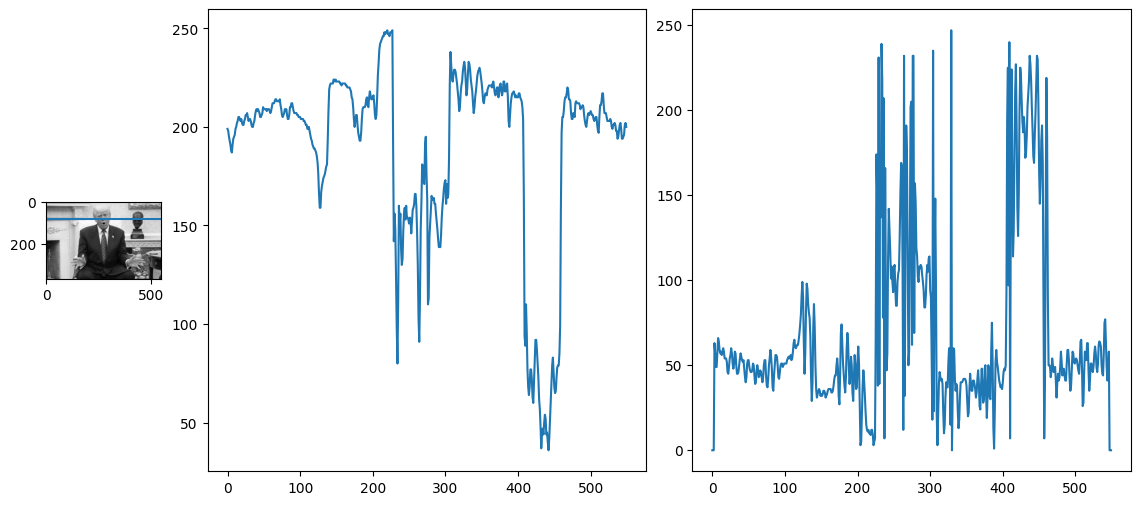

In [23]:
plt.figure(None, figsize=(14, 6))
grid = plt.GridSpec(1, 7, wspace=0.4, hspace=0.3)
plt.subplot(grid[0, 0])
plt.imshow(mrimg,cmap='gray')
plt.plot((0,mrimg.shape[1]-1),(cuty,cuty))
plt.subplot(grid[0, 1:4])
plt.plot(oneline)
plt.subplot(grid[0, 4:])
plt.plot(newoneline)
plt.show()

## Filtering in 2D
Let's take the simple averaging filter and run it across the image.

In [24]:
weights2d = [
    (1,1,1),
    (1,1,1),
    (1,1,1)
]
weights2d = np.array(weights2d)
weights2d = 1/np.sum(weights2d)*weights2d

In [25]:
filteredmrimg = np.zeros_like(mrimg)
for i in range(1,mrimg.shape[1]-1):
    for j in range(1,mrimg.shape[0]-1):
        filteredmrimg[j,i]=np.sum(weights2d*mrimg[j-1:j+2,i-1:i+2])

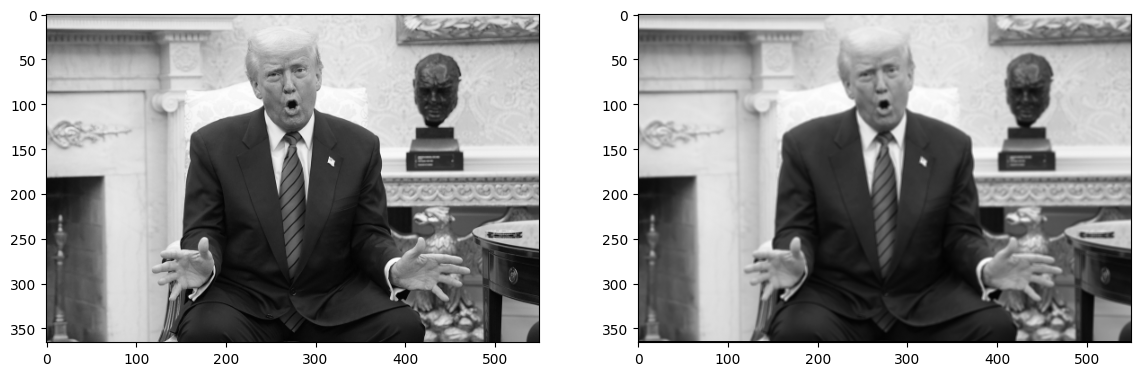

In [26]:
plt.figure(None, figsize=(14, 6))
plt.subplot(1,2,1)
plt.imshow(mrimg,cmap='gray')
plt.subplot(1,2,2)
plt.imshow(filteredmrimg,cmap='gray')
plt.show()

In [27]:
# this function will filter an roi using a set of weights
def filter_and_plot(weights,roi):
    # these two lines are important as they ensure correct
    # computations!
    weights = weights.astype(float)
    roi = roi.astype(float)
    # this holds the end result
    filtered = np.zeros_like(roi)
    width = int((weights.shape[1]-1)/2)
    height = int((weights.shape[0]-1)/2)
    # do the filtering
    for i in range(height,roi.shape[1]-height):
        for j in range(width,roi.shape[0]-width):
            filtered[j,i]=np.sum(weights*roi[j-width:j+width+1,i-height:i+height+1])
    # plot the original, the filter, and the filtered image
    plt.figure(None, figsize=(14, 6))
    grid = plt.GridSpec(1, 7, wspace=0.4, hspace=0.3)
    plt.subplot(grid[0, 0:3])
    plt.imshow(roi,cmap='gray')
    plt.subplot(grid[0, 3])
    extent = (0, weights.shape[1], weights.shape[0], 0)
    plt.imshow(weights,cmap='gray',extent=extent)
    plt.axis('off')
    if width<5:
        for i in range(0,len(weights)):
            for j in range(0,len(weights)):
                if weights[i,j]>0.5*np.max(weights):
                    plt.text(j+0.1,i+0.6,'{0:.2f}'.format(weights[i,j]),color='black')
                else:
                    plt.text(j+0.1,i+0.6,'{0:.2f}'.format(weights[i,j]),color='white')
    plt.grid(True)
    plt.subplot(grid[0, 4:])
    plt.imshow(filtered,cmap='gray')
    plt.show()
    return(filtered)

In [53]:
faceroi = mrimg[15:135,205:325]

## Different filters
Let's try out a few simple filters.

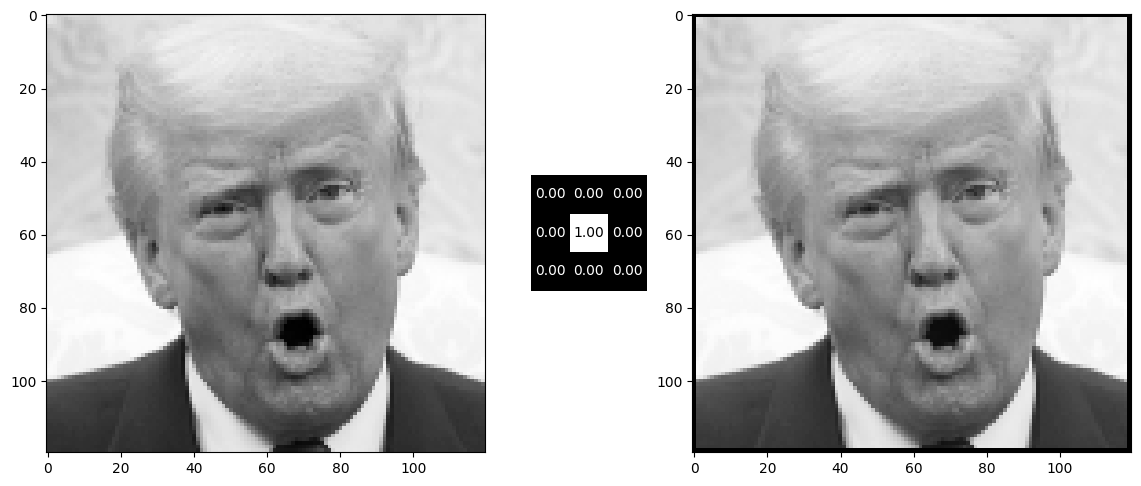

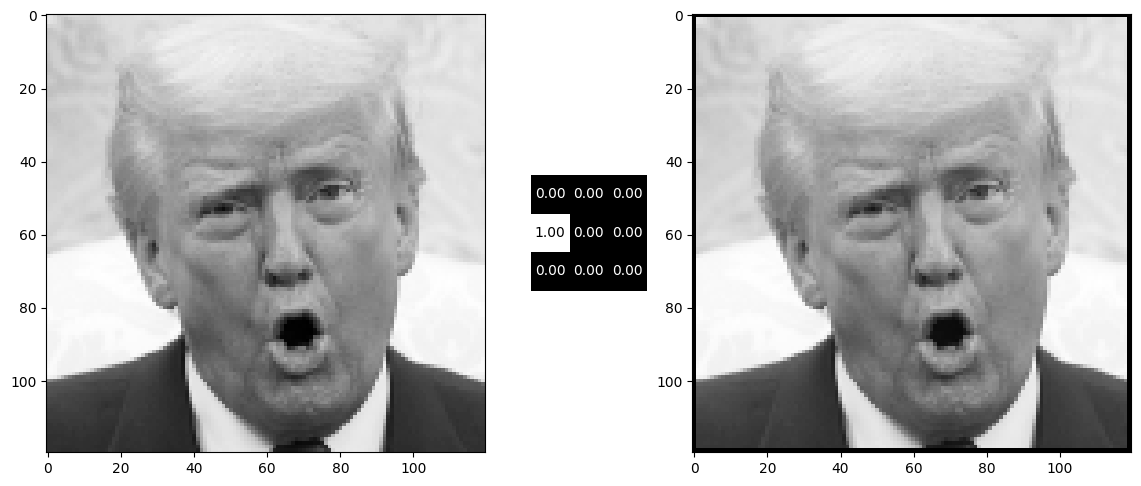

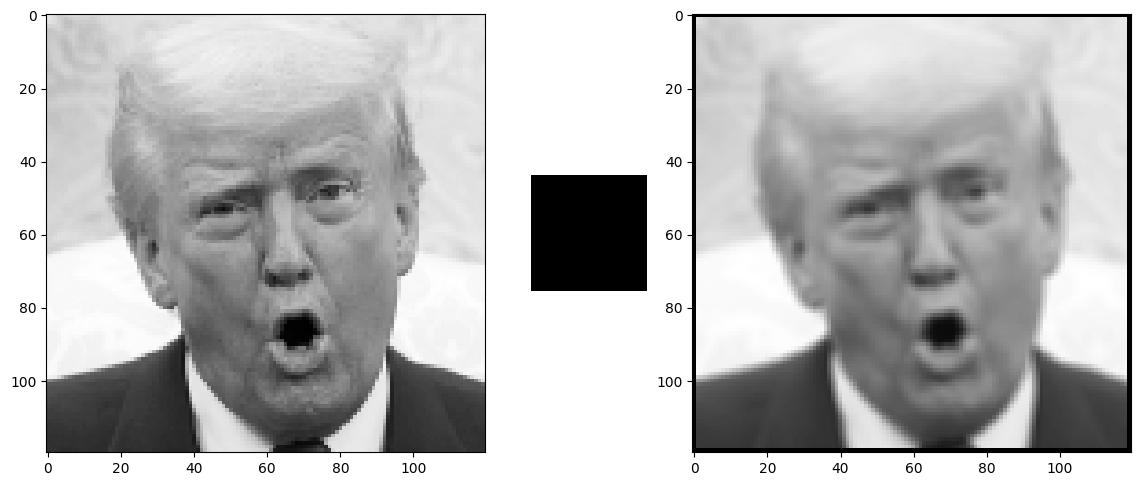

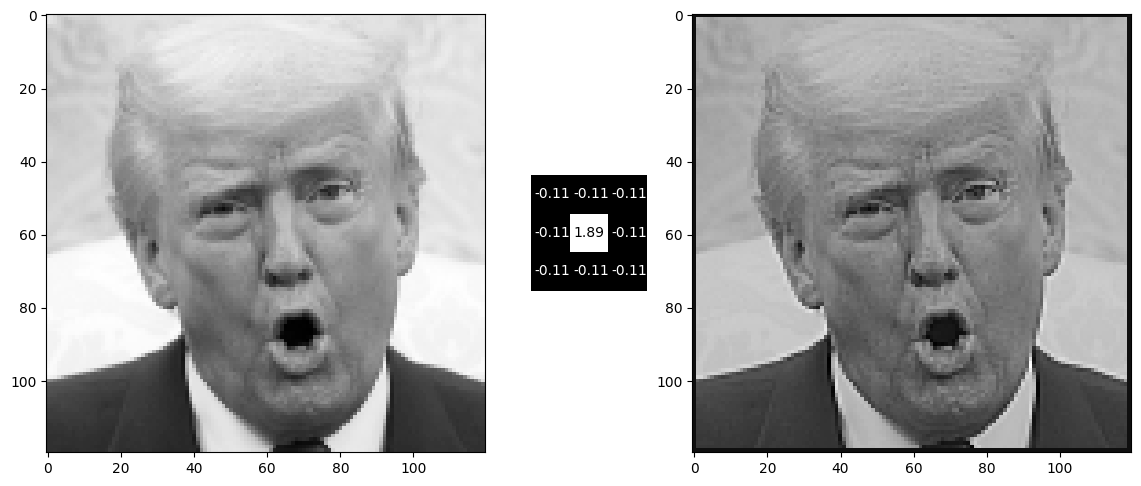

In [54]:
filter_id = np.array([
    (0,0,0),
    (0,1,0),
    (0,0,0)
])
filter_id = 1/np.sum(filter_id)*filter_id

filter_and_plot(filter_id,faceroi)

filter_left = np.array([
    (0,0,0),
    (1,0,0),
    (0,0,0)
])
filter_left = 1/np.sum(filter_left)*filter_left


filter_and_plot(filter_left,faceroi)

filter_blur = np.array([
    (1,1,1),
    (1,1,1),
    (1,1,1)
])
filter_blur = 1/np.sum(filter_blur)*filter_blur


filter_and_plot(filter_blur,faceroi)


filter_contrast = 2*filter_id - filter_blur
filter_contrast = 1/np.sum(filter_contrast)*filter_contrast


fc = filter_and_plot(filter_contrast,faceroi)

## Larger blur
Let's use a bigger averaging filter and see its effects.

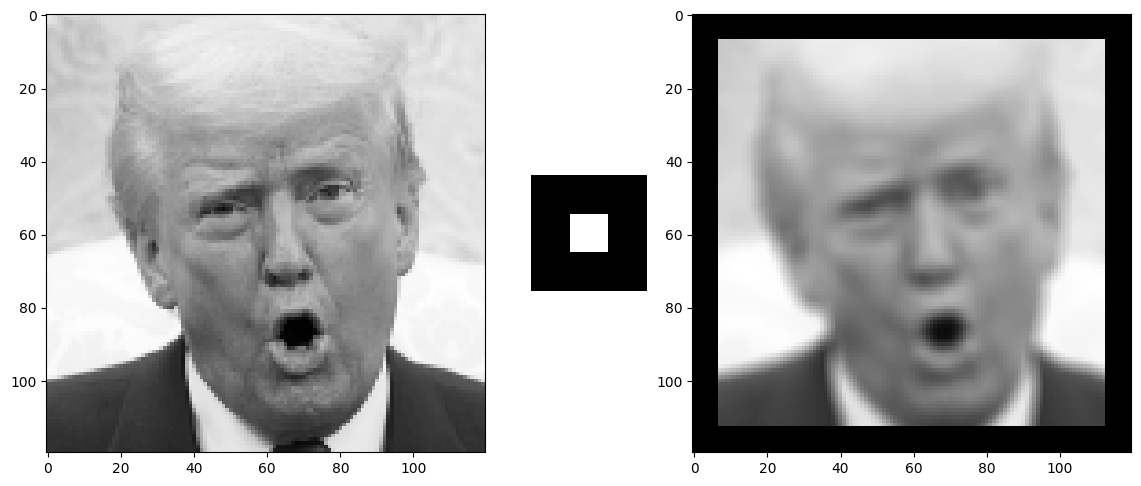

In [55]:
filter_blur_big = np.zeros((15,15))
filter_blur_big[5:10,5:10]=1
filter_blur_big = 1/np.sum(filter_blur_big)*filter_blur_big
f=filter_and_plot(filter_blur_big,faceroi)

## High-pass
Here's the difference between the blurred and the original iamge. Per definition it contains the high frequencies.

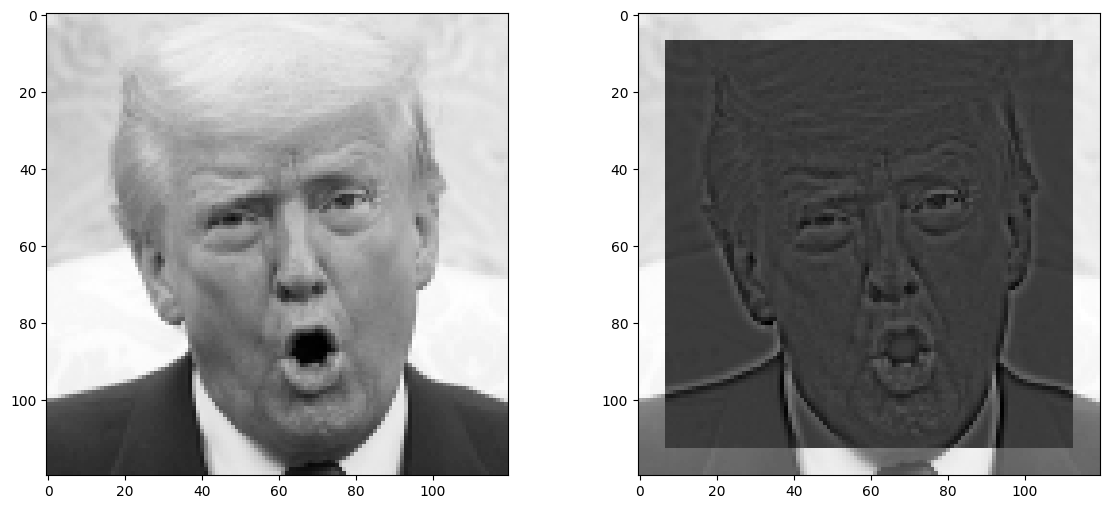

In [56]:
plt.figure(None, figsize=(14, 6))
plt.subplot(1,2,1)
plt.imshow(faceroi,cmap='gray')
plt.subplot(1,2,2)
diffimg = faceroi-f.astype(float)
plt.imshow(diffimg,cmap='gray')
plt.show()

## Gradual sharpening
Let's add more and more of the difference image to the blurred image

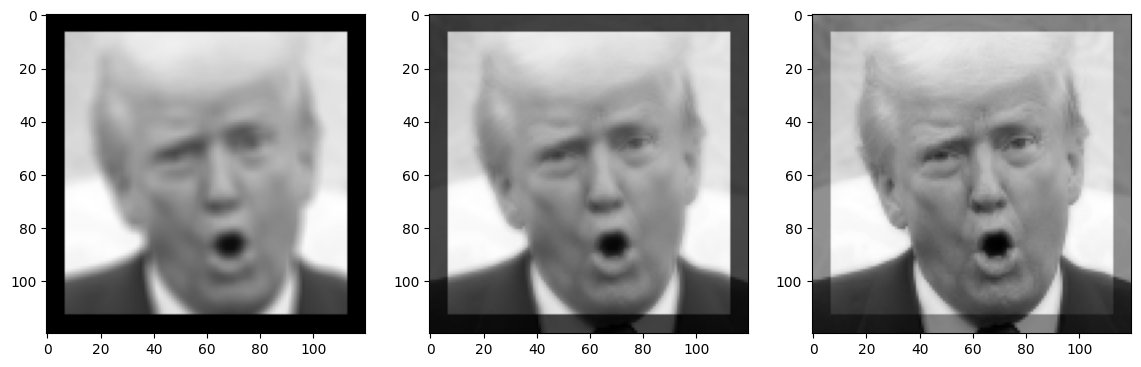

In [57]:
plt.figure(None, figsize=(14, 6))
plt.subplot(1,3,1)
plt.imshow(f,cmap='gray')
plt.subplot(1,3,2)
f = f.astype(float)
plt.imshow(f+0.3*diffimg,cmap='gray')
plt.subplot(1,3,3)
plt.imshow(f+0.6*diffimg,cmap='gray')
plt.show()

## Derivatives
Now, let's derive our image function using the simple derivative approximation.

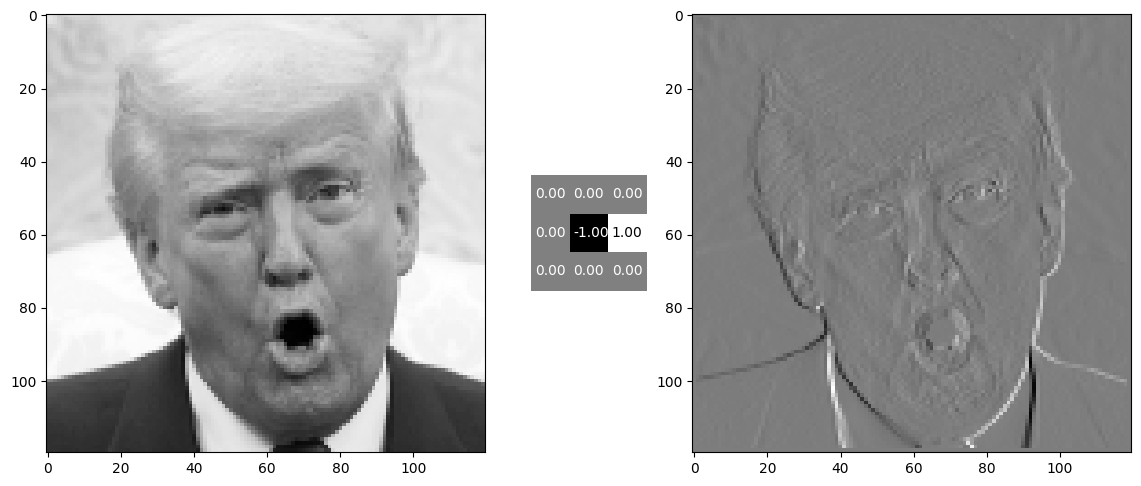

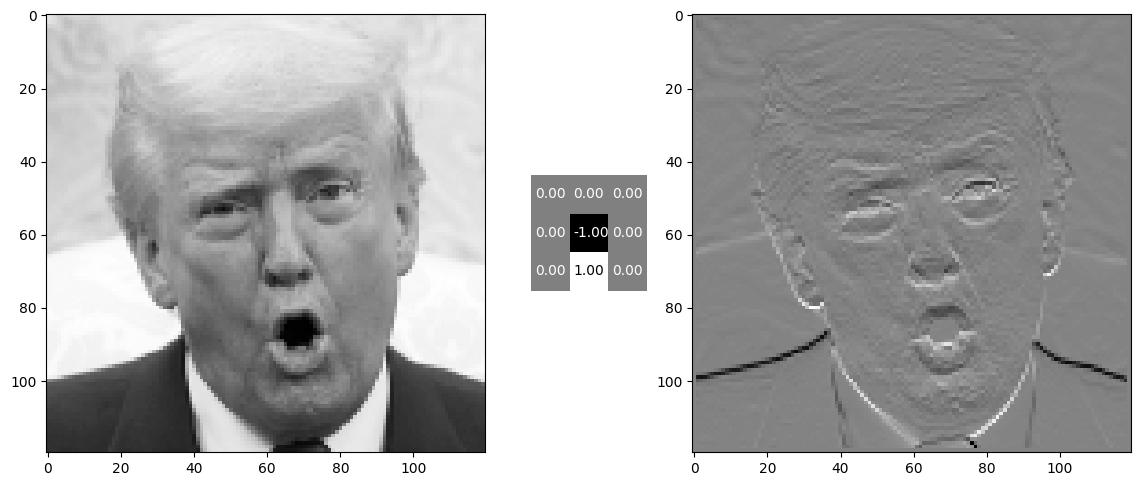

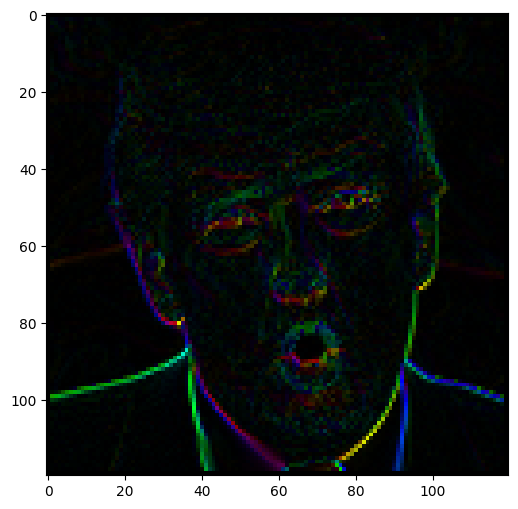

In [58]:
filter_dx = np.array([
    (0,0,0),
    (0,-1,1),
    (0,0,0)
])
fdx=filter_and_plot(filter_dx,faceroi)

filter_dy = np.array([
    (0,0,0),
    (0,-1,0),
    (0,1,0)
])
fdy=filter_and_plot(filter_dy,faceroi)

plt.figure(None, figsize=(6, 6))
hsv = np.zeros((fdx.shape[1],fdx.shape[0],3))
hsv[...,1] = 255
ang = np.arctan2(fdx,fdy)
hsv[...,0] = ang*180/np.pi
mag = np.sqrt(fdx*fdx+fdy*fdy)
hsv[...,2] = (mag-np.min(mag))/(np.max(mag)-np.min(mag))*255
plt.imshow(cv.cvtColor(np.uint8(hsv),cv.COLOR_HSV2RGB_FULL))
plt.show()

## Sobel filter
Let's implement the simple Gaussian derivative filter approximation - the Sobel filters.

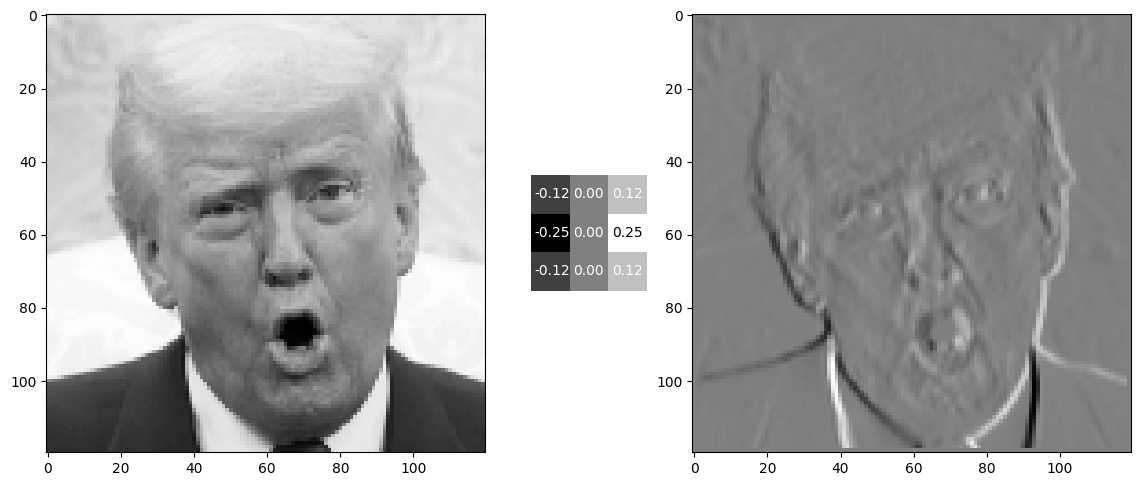

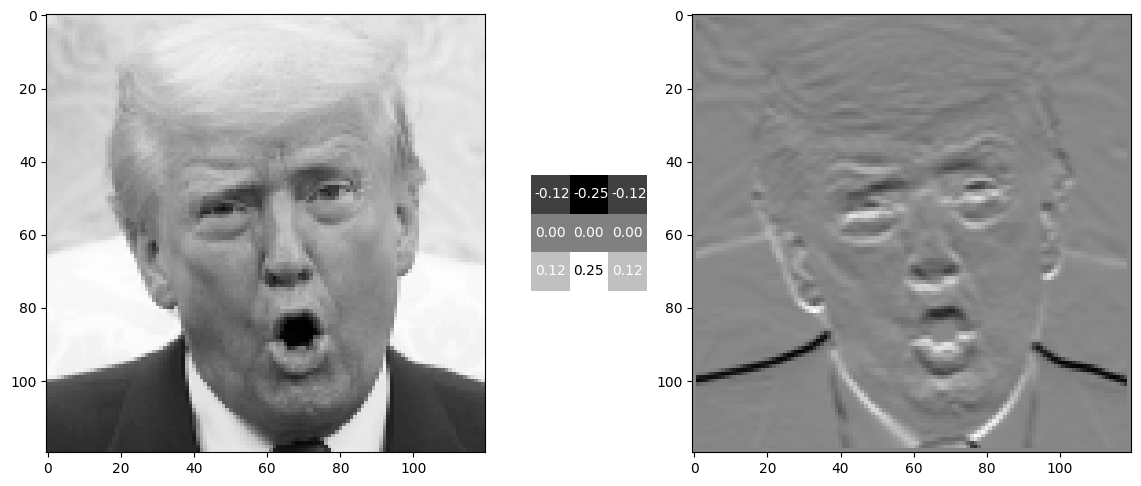

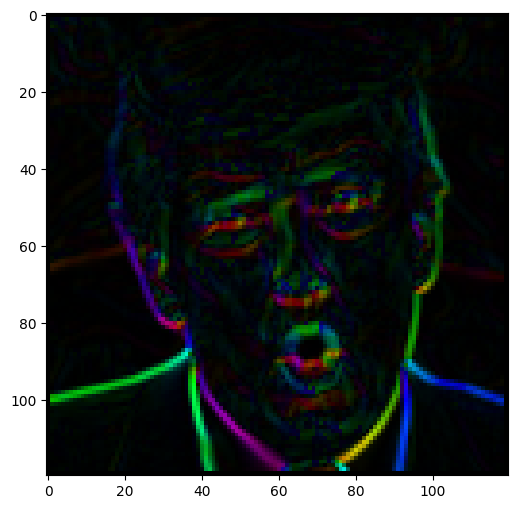

In [59]:
filter_sobelx = np.array([
    (-1,0,1),
    (-2,0,2),
    (-1,0,1)
])
fsx=filter_and_plot(1/8*filter_sobelx,faceroi)

filter_sobely = np.array([
    (-1,-2,-1),
    (0,0,0),
    (1,2,1)
])
fsy=filter_and_plot(1/8*filter_sobely,faceroi)

plt.figure(None, figsize=(6, 6))
hsv = np.zeros((fsx.shape[1],fsx.shape[0],3))
hsv[...,1] = 255
ang = np.arctan2(fsx,fsy)
hsv[...,0] = ang*180/np.pi
mag = np.sqrt(fsx*fsx+fsy*fsy)
hsv[...,2] = (mag-np.min(mag))/(np.max(mag)-np.min(mag))*255
plt.imshow(cv.cvtColor(np.uint8(hsv),cv.COLOR_HSV2RGB_FULL))
plt.show()

In [62]:
import cv2 as cv

def load_image(filename='./Trump.jpg'):
    img = cv.imread(filename)

    # cropping image
    top = 10 
    w_center = int(img.shape[1] / 2)
    img = img[top:top+500, w_center-250:w_center+250]
    return img

img = load_image()


In [60]:
def filter(image, kernel):
    image = image.astype(float)
    kernel = kernel.astype(float)
    
    filtered = np.zeros_like(image)
    width = int((kernel.shape[1]-1)/2)
    height = int((kernel.shape[0]-1)/2)

    for i in range(height, image.shape[1]-height):
        for j in range(width, image.shape[0]-width):
            filtered[j,i]=np.sum(kernel*image[j-width:j+width+1,i-height:i+height+1])

    return filtered

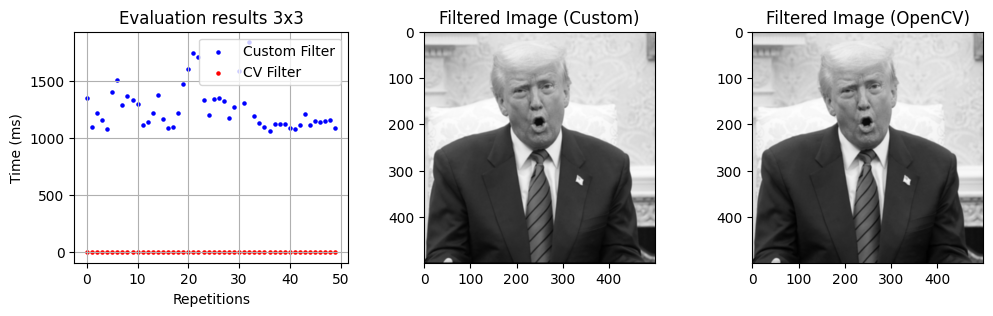

Evaluation Results for Size 3x3:
Custom Filter: Mean = 1260.2816, Std = 184.6108
OpenCV Filter: Mean = 0.1999, Std = 0.3998


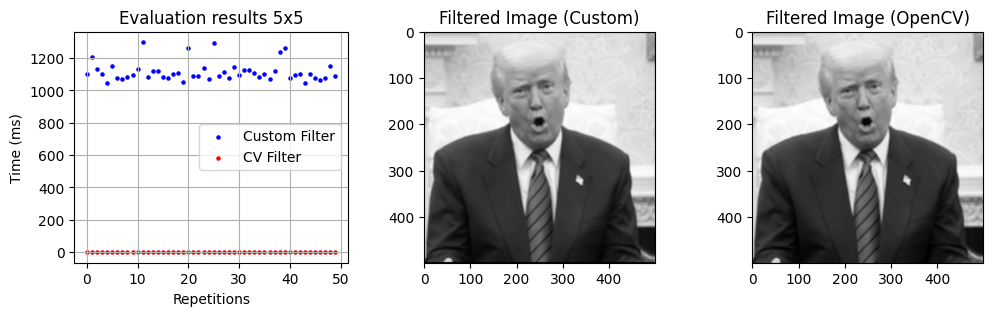

Evaluation Results for Size 5x5:
Custom Filter: Mean = 1115.8351, Std = 59.6929
OpenCV Filter: Mean = 0.5315, Std = 0.5168


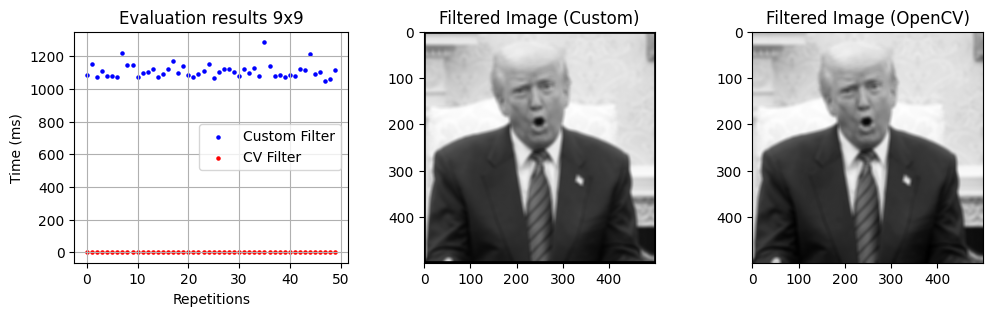

Evaluation Results for Size 9x9:
Custom Filter: Mean = 1109.4914, Std = 42.7611
OpenCV Filter: Mean = 1.7001, Std = 0.6777


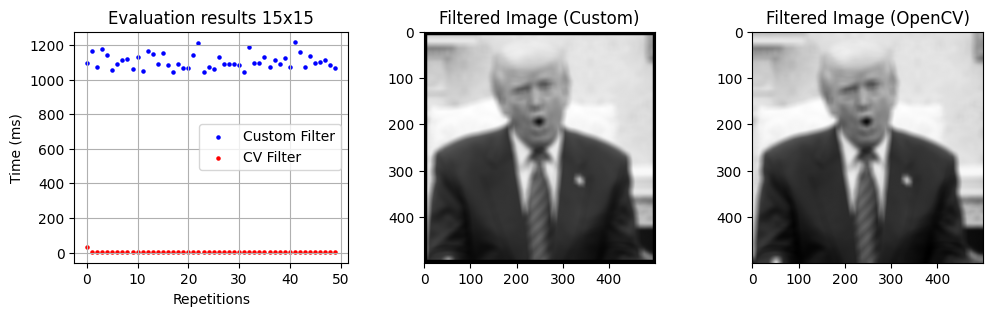

Evaluation Results for Size 15x15:
Custom Filter: Mean = 1105.2799, Std = 42.4321
OpenCV Filter: Mean = 3.5427, Std = 4.1949


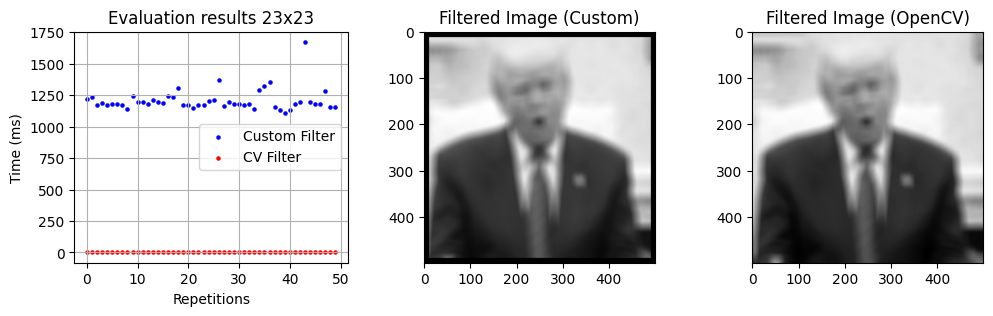

Evaluation Results for Size 23x23:
Custom Filter: Mean = 1207.9179, Std = 85.2004
OpenCV Filter: Mean = 3.0768, Std = 0.5644


In [63]:
import time
import numpy as np


# Measures the execution time of a given filter function over multiple repetitions
def record(filter_func, reps=50):
    results = []
    for _ in range(reps):
        start = time.time()
        img = filter_func()
        end = time.time()
        elapsed = (end - start) * 1000
        results.append(elapsed)

    return (results, img)

# Plots timing results and filtered images for both custom and OpenCV filters
def plot_results(title, custom, cv):
    custom_result, custom_img = custom
    cv_result, cv_img = cv

    figure = plt.figure(figsize=(12, 3))

    # Timing comparison scatter plot
    ax = figure.add_subplot(131)
    ax.scatter(range(len(custom_result)), custom_result, label='Custom Filter', color='blue', s=5)
    ax.scatter(range(len(cv_result)), cv_result, label='CV Filter', color='red', s=5)
    ax.set_xlabel('Repetitions')
    ax.set_ylabel('Time (ms)')
    ax.legend()
    ax.grid(True)
    ax.set_title(title)

    # Display image filtered by custom implementation
    ax = figure.add_subplot(132)
    ax.imshow(custom_img, cmap='gray')
    ax.set_title('Filtered Image (Custom)')

    # Display image filtered by OpenCV
    ax = figure.add_subplot(133)
    ax.imshow(cv_img, cmap='gray')
    ax.set_title('Filtered Image (OpenCV)')
    plt.show()


# Prints mean and standard deviation of execution times for both filters
def summary_results(index, custom, cv):
    custom_result, _ = custom
    cv_result, _ = cv
    
    custom_mean = np.mean(custom_result)
    cv_mean = np.mean(cv_result)

    custom_std = np.std(custom_result)
    cv_std = np.std(cv_result)

    print(f"Evaluation Results for Size {index}x{index}:")
    print(f"Custom Filter: Mean = {custom_mean:.4f}, Std = {custom_std:.4f}")
    print(f"OpenCV Filter: Mean = {cv_mean:.4f}, Std = {cv_std:.4f}")


# Performs full evaluation for multiple filter sizes and plots results
def evaluate():
    img = load_image()
    img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    filter_sizes = [3, 5, 9, 15, 23]
    reps = 50

    for size in filter_sizes:
        # normalized box filter
        box_filter = np.ones((size, size)) / (size * size)

        # Record performance using Custom filter
        func = lambda: filter(img, box_filter)
        custom_result = record(func, reps=reps)

        # Record performance using OpenCV filter
        func = lambda: cv.filter2D(img, -1, box_filter)
        cv_result = record(func, reps=reps)

        plot_results(f'Evaluation results {size}x{size}', custom_result, cv_result)
        summary_results(size, custom_result, cv_result)

evaluate()
